# 01 · Dataset audit (protocol §2, §8)

Before any model sees a diagnostic label, we establish *who* is in the analysis and *why* anyone else is not. This notebook builds three things:
- the participant manifest;
- the sample-flow table;
- the descriptive tables.

It runs now on synthetic examples. Set `USE_REAL_DATA = True` at the end once the data are in place.

## COBRE and the data it provides
- **COBRE** (Center for Biomedical Research Excellence, Mind Research Network, Albuquerque) is an openly shared dataset. For each participant it contains a T1-weighted anatomical scan, a resting-state fMRI scan, and phenotype information (diagnosis, age, sex), for patients with schizophrenia-spectrum disorders and for healthy controls.
- **"Openly accessible" does not mean "no rules".** Access is governed by data-use terms, so the data are not redistributed in this repository. `data/README.md` records the source, access date and checksums; this record is called **provenance**.
- nilearn's old `fetch_cobre` downloader was removed in nilearn 0.9, so the data are obtained directly.

## BIDS
The **Brain Imaging Data Structure** is a standard folder and file-naming layout, for example:
```
sub-0040000/anat/sub-0040000_T1w.nii.gz
sub-0040000/func/sub-0040000_task-rest_bold.nii.gz     (+ .json "sidecar" with TR, TE, scanner)
participants.tsv                                        (one row per participant: diagnosis, age, sex …)
```
fMRIPrep requires BIDS input, and the audit below relies on the standard names to find each participant's files.

## Single site and transportability
COBRE was acquired at a single site on a single scanner. The audit verifies this from the JSON sidecars.

- **What CV can estimate:** performance for *new participants from the same setting*.
- **What it cannot estimate:** **transportability**, i.e. how the model would perform at other hospitals, on other scanners, or in other populations. Every COBRE participant shares the same scanner, protocol and recruitment pathway, so a classifier could even learn site-specific quirks that would not carry over elsewhere.

## The primary sample-definition rule
The **analysis sample** is defined by a rule written before modelling, not by whoever happens to have files. A participant is included only if they have:
1. a valid diagnostic label;
2. recorded age and sex;
3. a raw T1w scan **and** a raw resting-state BOLD scan;
4. a FreeSurfer reconstruction that completed and passed visual QC, rated by someone blinded to diagnosis;
5. exactly one preprocessed resting BOLD run that passes the motion criteria (below).

**Why the intersection matters.** MKL needs *both* modalities. Every model must therefore be trained and tested on the same participants; otherwise a model comparison would partly reflect different samples rather than different models.

### Exclusion flow table
- Exclusion reasons are checked in a fixed order.
- Each excluded participant is counted under the **first** reason that applies, as in a CONSORT diagram, so the numbers add up: initial N − exclusions = final N.
- The manifest keeps *every* reason that applies to each participant.

### Missing data
- **Missingness mechanisms.** Data can be missing:
  - completely at random;
  - at random given observed variables;
  - not at random, e.g. patients who moved more are more likely to have unusable scans.

  The last case can bias the sample, which is why exclusions are also described **by group**.
- **No imputation.** Filling in missing values would be one more data-dependent step, and it would have to be fitted within training folds. The protocol avoids it: it analyses complete cases and reports who was excluded and why.

### Blinded quality control
The person rating structural QC does not know each participant's diagnosis. Otherwise, borderline scans might be kept or dropped differently in the two groups.

## Mapping raw phenotype values (diagnosis, sex, subtype)
Phenotype files are messy:
- one category can be written `Patient`, ` patient ` or `PATIENT`;
- missing entries appear as empty cells, `NaN`, `None`, `unknown` or `not reported`;
- a converted spreadsheet may contain the literal text `"nan"`, which is what `str(np.nan)` produces, and a naive `str(raw).strip()` would treat that as a real value.

The audit therefore applies four rules (protocol §2.4):

1. **Missing stays missing.** `None`, NaN/NA, empty or whitespace-only strings, and every token in `missing_values` (in `configs/data_config.yaml`) are treated as *missing* and mapped to `None`. A missing diagnosis gives the exclusion reason `missing_label`, and a missing age or sex gives `missing_covariate`.
2. **Matching ignores case and whitespace.** `"Patient"`, `" patient "` and `"PATIENT"` all match a config entry `Patient`. Numbers are compared in integer form, so a sex column stored as `1.0` matches a config entry `1`.
3. **Unrecognized values stop the audit.** A non-missing value that the config does not list, such as a typo or an unanticipated category, is **never** silently turned into "missing". The audit collects every such value, prints how often each occurs, and refuses to write the manifest until each one is:
   - mapped to a category, or
   - declared missing, or
   - declared non-analysable.
4. **Known non-analysable labels are explicit.** Values such as `Disenrolled` go under `label_map.exclude`. Those participants get their own exclusion reason, `excluded_label`, so the flow table shows them separately from truly missing labels.

The config itself is also checked:
- a value mapped to two categories is an error;
- a category value that is also a missing token is an error;
- a configured value that never occurs in the data triggers a warning, since that is usually a typo.

## Head-motion metrics used for functional QC
Head motion is the largest artifact in fMRI, and it tends to differ between patients and controls. It is therefore both a QC criterion and a potential **confound** (notebook 07).

### Framewise displacement (FD)
FD (Power et al., 2012) summarises how far the head moved between consecutive volumes $t-1$ and $t$. It uses the 6 realignment parameters: 3 translations in mm and 3 rotations in radians.

$$\mathrm{FD}_t = |\Delta d_x| + |\Delta d_y| + |\Delta d_z| + 50\,\big(|\Delta\alpha| + |\Delta\beta| + |\Delta\gamma|\big)$$

Rotations are converted to millimetres of movement on a sphere of radius 50 mm, roughly the distance from the centre of the brain to the cortex.

### DVARS
DVARS is the root-mean-square change in signal intensity across the brain from one volume to the next. *Standardized* DVARS divides it by its expected value, so values well above 1 flag sudden jumps in signal.

### Censoring (scrubbing)
Volumes with FD > 0.5 mm or standardized DVARS > 1.5 are removed before connectivity is computed. A participant is **excluded** if any of the following holds:
- mean FD > 0.55 mm;
- any single FD > 5 mm;
- less than 180 s of data remain after censoring.

In [1]:
from pathlib import Path
from collections import Counter
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
# Exclusion reasons, in the order used by the sequential flow table (protocol §2.3).
REASONS = (
    "missing_label",
    "excluded_label",
    "missing_covariate",
    "missing_structural",
    "missing_functional",
    "failed_structural_qc",
    "failed_functional_qc",
)
FS_STATS = ("lh.aparc.stats", "rh.aparc.stats", "aseg.stats")
ACQ_FIELDS = ("Manufacturer", "ManufacturersModelName", "MagneticFieldStrength",
              "SoftwareVersions", "RepetitionTime", "EchoTime")
# Used when configs/data_config.yaml has no ``missing_values`` entry.
DEFAULT_MISSING_VALUES = ("", "na", "n/a", "nan", "none", "null", "unknown", "not reported", "missing", "-", "?")


class UnmappedValueError(ValueError):
    """A non-missing phenotype value that the config does not recognize."""

    def __init__(self, field, raw, problem="not listed in the config"):
        super().__init__(f"{field}: {raw!r} is {problem}")
        self.field, self.raw = field, raw


def _canonical(value):
    """Comparable text: integral numbers without decimals, whitespace collapsed, case folded."""
    if isinstance(value, (bool, np.bool_)):
        return str(bool(value)).casefold()
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)):
        value = float(value)
        return str(int(value)) if value.is_integer() else repr(value)
    return " ".join(str(value).split()).casefold()


def normalize_value(raw, missing_values=DEFAULT_MISSING_VALUES):
    """Canonical form of a raw phenotype value, or None if it is missing.

    Missing means None, NaN/NA, an empty or whitespace-only string, or any token in
    ``missing_values`` (compared case- and whitespace-insensitively).
    """
    if raw is None or (np.ndim(raw) == 0 and pd.isna(raw)):
        return None
    text = _canonical(raw)
    return None if text in {_canonical(v) for v in missing_values} else text


def value_lookup(mapping, missing_values=DEFAULT_MISSING_VALUES):
    """{canonical raw value: category}; rejects values listed twice or listed as missing tokens."""
    lookup = {}
    for category, values in mapping.items():
        for value in values or []:
            key = normalize_value(value, missing_values)
            if key is None:
                raise ValueError(f"{value!r} (under {category!r}) is a missing-value token and cannot be a category.")
            if lookup.get(key, category) != category:
                raise ValueError(f"{value!r} is mapped to both {lookup[key]!r} and {category!r}.")
            lookup[key] = category
    return lookup


def map_value(raw, mapping, field="value", missing_values=DEFAULT_MISSING_VALUES):
    """Category of a raw phenotype value (protocol §2.4).

    Returns None if the value is missing, and raises UnmappedValueError if it is
    non-missing but not listed in ``mapping``: unexpected values are never silently
    treated as missing.
    """
    key = normalize_value(raw, missing_values)
    if key is None:
        return None
    lookup = value_lookup(mapping, missing_values)
    if key not in lookup:
        raise UnmappedValueError(field, raw)
    return lookup[key]


def parse_number(raw, field="value", missing_values=DEFAULT_MISSING_VALUES):
    """Float value, None if missing; UnmappedValueError if the value is not a number."""
    if normalize_value(raw, missing_values) is None:
        return None
    try:
        return float(raw)
    except (TypeError, ValueError):
        raise UnmappedValueError(field, raw, "not a number") from None


def bids_id(raw):
    """'0040000' or 'sub-0040000' -> 'sub-0040000'."""
    raw = str(raw).strip()
    return raw if raw.startswith("sub-") else f"sub-{raw}"


def _stem(nifti):
    name = nifti.name
    return name[:-7] if name.endswith(".nii.gz") else name[:-4]


def sidecar(nifti, bids_dir, suffix):
    """Acquisition fields from the BIDS JSON sidecar, with top-level inheritance."""
    fields = {}
    for path in (bids_dir / f"task-rest_{suffix}.json" if suffix == "bold" else None,
                 nifti.parent / f"{_stem(nifti)}.json"):
        if path is not None and path.exists():
            fields.update(json.loads(path.read_text()))
    return {key: fields.get(key) for key in ACQ_FIELDS}


def load_visual_qc(path):
    """{participant_id: 1, 0 or NaN} from the blinded structural visual-QC ratings file.

    qc_pass must be 1 (pass), 0 (fail) or empty (not rated yet); anything else is an error.
    """
    if not path.exists():
        return {}
    table = pd.read_csv(path, dtype={"participant_id": str})
    ratings = [normalize_value(v) for v in table["qc_pass"]]
    bad = [(pid, raw) for pid, raw, r in zip(table["participant_id"], table["qc_pass"], ratings)
           if r is not None and r not in ("0", "1")]
    if bad:
        raise ValueError(f"qc_pass must be 1, 0 or empty; found: {bad}")
    return {bids_id(pid): (np.nan if r is None else int(r)) for pid, r in zip(table["participant_id"], ratings)}

In [3]:
def framewise_displacement(motion, radius=50.0):
    """Power FD from an (n_volumes, 6) array: 3 translations (mm) then 3 rotations (rad).

    The first volume has no predecessor, so its FD is NaN (as in fMRIPrep's confounds file).
    """
    steps = np.abs(np.diff(motion, axis=0))
    fd = steps[:, :3].sum(axis=1) + radius * steps[:, 3:].sum(axis=1)
    return np.concatenate([[np.nan], fd])


def motion_summary(preproc_bold, denoise_kwargs, qc):
    """Mean/max FD, retained volumes after censoring, and the functional QC decision."""
    import nibabel as nib
    from nilearn.interfaces.fmriprep import load_confounds_strategy

    prefix = preproc_bold.name.split("_space-")[0]
    confounds = pd.read_csv(preproc_bold.parent / f"{prefix}_desc-confounds_timeseries.tsv", sep="\t")
    fd = confounds["framewise_displacement"].to_numpy(float)
    _, sample_mask = load_confounds_strategy(str(preproc_bold), **denoise_kwargs)
    n_volumes = len(confounds)
    n_retained = n_volumes if sample_mask is None else len(sample_mask)
    tr = float(nib.load(str(preproc_bold)).header.get_zooms()[3])
    summary = {
        "mean_fd": float(np.nanmean(fd)),
        "max_fd": float(np.nanmax(fd)),
        "n_volumes": n_volumes,
        "n_retained": n_retained,
        "tr": tr,
        "retained_seconds": n_retained * tr,
    }
    summary["func_qc_pass"] = bool(summary["mean_fd"] <= qc["max_mean_fd_mm"]
                                   and summary["max_fd"] <= qc["max_fd_mm"]
                                   and summary["retained_seconds"] >= qc["min_retained_seconds"])
    return summary

In [4]:
LABEL_CATEGORIES = {"patient", "control", "exclude"}
SEX_CATEGORIES = {"male", "female"}


def build_manifest(cfg):
    """One row per phenotype participant: labels, covariates, file checks, QC, exclusions.

    Stops with a list of every unrecognized phenotype value instead of treating it as missing.
    """
    ph = cfg["phenotype"]
    missing_values = cfg.get("missing_values", DEFAULT_MISSING_VALUES)
    label_map, sex_map = cfg["label_map"], cfg["sex_map"]
    pheno = pd.read_csv(ROOT / ph["path"], sep=ph.get("sep", ","), dtype={ph["id_column"]: str})
    pheno.columns = [str(c).strip() for c in pheno.columns]
    if not label_map.get("patient") or not label_map.get("control"):
        print(pheno[ph["diagnosis_column"]].value_counts(dropna=False).to_string())
        raise ValueError("label_map in configs/data_config.yaml is empty. Map the raw diagnosis "
                         "values printed above to patient/control (protocol §2.4), then rerun.")
    for name, mapping, allowed in [("label_map", label_map, LABEL_CATEGORIES), ("sex_map", sex_map, SEX_CATEGORIES)]:
        unknown = set(mapping) - allowed
        if unknown:
            raise ValueError(f"{name} has unknown categories {sorted(unknown)}; allowed: {sorted(allowed)}")
        value_lookup(mapping, missing_values)          # fails early on ambiguous config entries

    bids = ROOT / cfg["bids_dir"]
    fmriprep = ROOT / cfg["fmriprep_dir"]
    freesurfer = ROOT / cfg["freesurfer_dir"]
    func, qc = cfg["functional"], cfg["qc"]
    visual_qc = load_visual_qc(ROOT / qc["structural_visual_qc"])
    subtype_column = ph.get("subtype_column") or ph["diagnosis_column"]
    strict_keys = {normalize_value(v, missing_values) for v in cfg.get("strict_patient_values") or []} - {None}

    rows, problems = [], Counter()
    seen = {"diagnosis": set(), "sex": set(), "subtype": set()}
    for _, record in pheno.iterrows():
        pid = bids_id(record[ph["id_column"]])
        mapped = {}
        for field, column, mapping in [("diagnosis", ph["diagnosis_column"], label_map), ("sex", ph["sex_column"], sex_map)]:
            seen[field].add(normalize_value(record[column], missing_values))
            try:
                mapped[field] = map_value(record[column], mapping, field, missing_values)
            except UnmappedValueError as err:
                problems[(err.field, err.raw)] += 1
                mapped[field] = None
        try:
            age = parse_number(record[ph["age_column"]], "age", missing_values)
        except UnmappedValueError as err:
            problems[(err.field, err.raw)] += 1
            age = None
        subtype = normalize_value(record[subtype_column], missing_values)
        seen["subtype"].add(subtype)

        label_status = {"patient": "patient", "control": "control", "exclude": "excluded", None: "missing"}[mapped["diagnosis"]]
        if label_status == "patient":
            strict = np.nan if subtype is None else int(subtype in strict_keys)   # unknown subtype stays unknown
        else:
            strict = 0
        row = {
            "participant_id": pid,
            "diagnosis_raw": record[ph["diagnosis_column"]],
            "label_status": label_status,
            "label": {"patient": 1, "control": 0}.get(label_status, np.nan),
            "strict_patient": strict,
            "age": np.nan if age is None else age,
            "sex_raw": record[ph["sex_column"]],
            "sex_male": {"male": 1, "female": 0}.get(mapped["sex"], np.nan),
            "mean_fd": np.nan, "max_fd": np.nan, "n_volumes": np.nan, "n_retained": np.nan,
            "tr": np.nan, "retained_seconds": np.nan, "func_qc_pass": False,
        }
        if ph.get("medication_column"):
            row["medication_raw"] = record[ph["medication_column"]]

        t1 = sorted((bids / pid).glob("**/anat/*_T1w.nii*"))
        bold = sorted((bids / pid).glob(f"**/func/*task-{func['task']}*_bold.nii*"))
        preproc = sorted((fmriprep / pid).glob(
            f"**/func/*task-{func['task']}*space-{func['space']}*res-{func['resolution']}"
            "*desc-preproc_bold.nii.gz"))
        row.update(n_t1=len(t1), n_bold=len(bold), n_preproc_bold=len(preproc))
        if t1:
            row.update({f"t1_{k}": v for k, v in sidecar(t1[0], bids, "T1w").items()})
        if bold:
            row.update({f"bold_{k}": v for k, v in sidecar(bold[0], bids, "bold").items()})
        row["fs_complete"] = all((freesurfer / pid / "stats" / f).exists() for f in FS_STATS)
        row["struct_visual_qc"] = visual_qc.get(pid, np.nan)
        if len(preproc) == 1:
            row.update(motion_summary(preproc[0], func["denoise"]["primary"], qc))
        rows.append(row)

    if problems:
        listing = "\n".join(f"  {field}: {raw!r}  ({n} participants)"
                            for (field, raw), n in sorted(problems.items(), key=lambda kv: (kv[0][0], str(kv[0][1]))))
        raise ValueError("Unrecognized phenotype values. Map each one in configs/data_config.yaml "
                         "(label_map / sex_map), add it to missing_values, or list it under "
                         "label_map.exclude, then rerun:\n" + listing)
    for field, mapping in [("diagnosis", label_map), ("sex", sex_map)]:
        unused = [v for values in mapping.values() for v in values or []
                  if normalize_value(v, missing_values) not in seen[field]]
        if unused:
            print(f"Warning: configured {field} values never found in the data (typo?): {unused}")
    if strict_keys - seen["subtype"]:
        print(f"Warning: strict_patient_values never found in the data (typo?): {sorted(strict_keys - seen['subtype'])}")
    return add_exclusions(pd.DataFrame(rows))


def add_exclusions(manifest):
    """Boolean ``excl_*`` column per reason, all reasons joined, and ``included``."""
    m = manifest.copy()
    if "label_status" in m:
        status = m["label_status"]
    else:
        status = pd.Series(np.where(m["label"].isna(), "missing", "labelled"), index=m.index)
    reasons = {
        "missing_label": status.eq("missing"),
        "excluded_label": status.eq("excluded"),
        "missing_covariate": m["age"].isna() | m["sex_male"].isna(),
        "missing_structural": m["n_t1"] < 1,
        "missing_functional": m["n_bold"] < 1,
        "failed_structural_qc": ~m["fs_complete"].eq(True) | ~m["struct_visual_qc"].eq(1),
        "failed_functional_qc": m["n_preproc_bold"].ne(1) | ~m["func_qc_pass"].eq(True),
    }
    for reason in REASONS:
        m[f"excl_{reason}"] = reasons[reason].to_numpy(bool)
    m["exclusion_reasons"] = [";".join(r for r in REASONS if m.at[i, f"excl_{r}"]) for i in m.index]
    m["included"] = (m["exclusion_reasons"] == "").astype(int)
    return m


def sample_flow(manifest):
    """Sequential flow table: each participant is counted under their first reason."""
    remaining = np.ones(len(manifest), dtype=bool)
    rows = [("initial_N", len(manifest))]
    for reason in REASONS:
        hit = manifest[f"excl_{reason}"].to_numpy(bool)
        rows.append((f"excluded_{reason}", int((remaining & hit).sum())))
        remaining &= ~hit
    final = manifest.loc[remaining]
    rows += [("final_N", len(final)),
             ("patients", int((final["label"] == 1).sum())),
             ("controls", int((final["label"] == 0).sum())),
             ("strict_patients", int(final["strict_patient"].sum()))]
    return pd.DataFrame(rows, columns=["step", "n"])


def describe_sample(manifest, stringent_fd):
    """Group descriptives of the included sample (potential confounds, protocol §8)."""
    included = manifest[manifest["included"] == 1]
    rows = []
    for label, group in included.groupby("label"):
        rows.append({
            "group": "patient" if label == 1 else "control",
            "n": len(group),
            "age_mean": group["age"].mean(), "age_sd": group["age"].std(),
            "male_n": int(group["sex_male"].sum()), "male_pct": 100 * group["sex_male"].mean(),
            "mean_fd_mean": group["mean_fd"].mean(), "mean_fd_sd": group["mean_fd"].std(),
            "retained_seconds_mean": group["retained_seconds"].mean(),
            f"n_mean_fd_above_{stringent_fd}": int((group["mean_fd"] > stringent_fd).sum()),
        })
    return pd.DataFrame(rows)

## Demo 1: how raw phenotype values are mapped
These raw diagnosis values are passed through `map_value` with a config that lists `Patient`, `Control` and `Disenrolled` (exclude).
- **Case and spacing variants** match.
- **Every form of missing** becomes `None`, which later becomes the exclusion reason `missing_label`.
- **The misspelling `"Pateint"`** is *not* silently treated as missing. It raises an error that names the value.

The second table shows numeric codes. In the NIAK phenotype file, sex is stored as `0.0`/`1.0` (0 = male).

In [5]:
label_map_demo = {"patient": ["Patient"], "control": ["Control"], "exclude": ["Disenrolled"]}
sex_map_demo = {"male": [0], "female": [1]}


def try_map(raw, mapping, field):
    try:
        result = map_value(raw, mapping, field)
        return "None (missing)" if result is None else result
    except UnmappedValueError as err:
        return f"ERROR: {err}"


diagnosis_examples = ["Patient", "  patient ", "PATIENT", "Control", "Disenrolled",
                      np.nan, None, "", "   ", "nan", "unknown", "Not Reported", "Pateint"]
display(pd.DataFrame({"raw diagnosis": [repr(v) for v in diagnosis_examples],
                      "mapped to": [try_map(v, label_map_demo, "diagnosis") for v in diagnosis_examples]}))
sex_examples = [0.0, 1.0, 0, "1", np.nan, 2.0]
display(pd.DataFrame({"raw sex": [repr(v) for v in sex_examples],
                      "mapped to": [try_map(v, sex_map_demo, "sex") for v in sex_examples]}))

for bad_config in [{"patient": ["Patient"], "control": ["patient"]}, {"patient": ["Patient", "unknown"], "control": ["Control"]}]:
    try:
        value_lookup(bad_config)
    except ValueError as err:
        print("config rejected:", err)

,raw diagnosis,mapped to
0,'Patient',patient
1,' patient ',patient
2,'PATIENT',patient
3,'Control',control
4,'Disenrolled',exclude
5,nan,None (missing)
6,None,None (missing)
7,'',None (missing)
8,' ',None (missing)
9,'nan',None (missing)


,raw sex,mapped to
0,0.0,male
1,1.0,female
2,0,male
3,'1',female
4,nan,None (missing)
5,2.0,ERROR: sex: 2.0 is not listed in the config


config rejected: 'patient' is mapped to both 'patient' and 'control'.
config rejected: 'unknown' (under 'patient') is a missing-value token and cannot be a category.


## Demo 2: framewise displacement from realignment parameters
This synthetic head-motion trace has a slow drift plus two sudden movements: a 0.8 mm shift and a small rotation. The red dashed line is the censoring threshold. Only the sudden movements cross it, and those volumes would be censored.

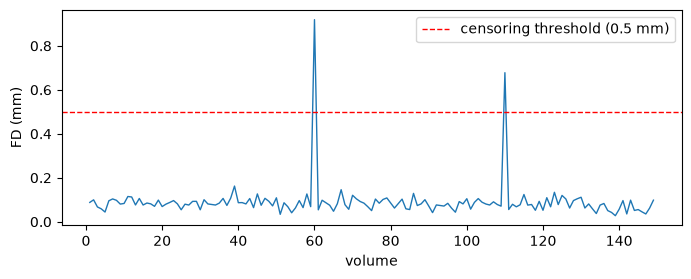

mean FD = 0.091 mm | max FD = 0.92 mm | volumes above 0.5 mm: 2


In [6]:
rng = np.random.default_rng(0)
n_volumes = 150
motion = np.cumsum(rng.normal(0, [0.02, 0.02, 0.02, 0.0003, 0.0003, 0.0003], size=(n_volumes, 6)), axis=0)
motion[60:, 2] += 0.8        # sudden 0.8 mm shift in z at volume 60
motion[110:, 3] += 0.012     # sudden 0.012 rad rotation (~0.6 mm at 50 mm) at volume 110
fd = framewise_displacement(motion)

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot(fd, lw=1)
ax.axhline(0.5, color="red", ls="--", lw=1, label="censoring threshold (0.5 mm)")
ax.set_xlabel("volume")
ax.set_ylabel("FD (mm)")
ax.legend()
plt.show()
print(f"mean FD = {np.nanmean(fd):.3f} mm | max FD = {np.nanmax(fd):.2f} mm | "
      f"volumes above 0.5 mm: {(fd > 0.5).sum()}")

## Demo 3: exclusions and the sample-flow table
The synthetic manifest below has the same columns as the real audit output, and each row illustrates one situation.

Things to notice:
- `sub-05` has no T1 scan, so it also has no FreeSurfer reconstruction. Two reasons apply, but the flow table counts it only once, under the first.
- `sub-08` has not been visually rated yet. An unrated scan counts as a failure, so it can never slip into the sample unnoticed.
- `sub-12` was marked `Disenrolled`. It is counted separately from `sub-03`, whose diagnosis is simply missing.

In [7]:
base = dict(label_status="patient", label=1, age=34.0, sex_male=1, n_t1=1, n_bold=1, fs_complete=True,
            struct_visual_qc=1, n_preproc_bold=1, func_qc_pass=True, strict_patient=1,
            mean_fd=0.15, retained_seconds=280.0)
control = {"label_status": "control", "label": 0, "strict_patient": 0}
situations = {
    "sub-01": {},                                                         # complete patient
    "sub-02": {**control, "age": 31.0, "mean_fd": 0.10},                  # complete control
    "sub-03": {"label_status": "missing", "label": np.nan},               # no usable diagnosis
    "sub-04": {"age": np.nan},                                            # age missing
    "sub-05": {"n_t1": 0, "fs_complete": False},                          # no T1 scan
    "sub-06": {"n_bold": 0, "n_preproc_bold": 0, "func_qc_pass": False},  # no BOLD scan
    "sub-07": {"struct_visual_qc": 0},                                    # failed structural visual QC
    "sub-08": {"struct_visual_qc": np.nan},                               # QC not rated yet
    "sub-09": {"func_qc_pass": False, "mean_fd": 0.7},                    # too much head motion
    "sub-10": {**control, "age": 40.0, "sex_male": 0, "mean_fd": 0.12},   # complete control
    "sub-11": {"age": 29.0, "mean_fd": 0.21},                             # complete patient
    "sub-12": {"label_status": "excluded", "label": np.nan},              # diagnosis "Disenrolled"
}
demo = pd.DataFrame([{"participant_id": pid, **base, **extra} for pid, extra in situations.items()])
manifest_demo = add_exclusions(demo)
display(manifest_demo[["participant_id", "label_status", "exclusion_reasons", "included"]])
display(sample_flow(manifest_demo))

,participant_id,label_status,exclusion_reasons,included
0,sub-01,patient,,1
1,sub-02,control,,1
2,sub-03,missing,missing_label,0
3,sub-04,patient,missing_covariate,0
4,sub-05,patient,missing_structural;failed_structural_qc,0
5,sub-06,patient,missing_functional;failed_functional_qc,0
6,sub-07,patient,failed_structural_qc,0
7,sub-08,patient,failed_structural_qc,0
8,sub-09,patient,failed_functional_qc,0
9,sub-10,control,,1


,step,n
0,initial_N,12
1,excluded_missing_label,1
2,excluded_excluded_label,1
3,excluded_missing_covariate,1
4,excluded_missing_structural,1
5,excluded_missing_functional,1
6,excluded_failed_structural_qc,2
7,excluded_failed_functional_qc,1
8,final_N,4
9,patients,2


## Class imbalance
**Class imbalance** means one label is much more common than the other. COBRE is roughly balanced, but individual folds can still end up slightly unequal. The protocol deals with this in three ways:
- **stratified** splits, so every fold keeps the overall patient/control ratio (notebook 05);
- `class_weight="balanced"` in the SVM, so errors on the smaller class cost proportionally more (notebook 04);
- reporting **PR-AUC together with its chance level**, and **balanced accuracy**, alongside ROC-AUC (notebook 06).

## Describing the sample before modelling
A **confound** is a variable associated with diagnosis *and* with the MRI features (notebook 07). Age, sex, head motion and data quality can all act as confounds, so they are described by group here, before any model is fitted.

In [8]:
display(describe_sample(manifest_demo, stringent_fd=0.25))

,group,n,age_mean,age_sd,male_n,male_pct,mean_fd_mean,mean_fd_sd,retained_seconds_mean,n_mean_fd_above_0.25
0,control,2,35.5,6.363961,1,50.0,0.11,0.014142,280.0,0
1,patient,2,31.5,3.535534,2,100.0,0.18,0.042426,280.0,0


## Run the audit on the real data
Steps (protocol §2, `data/README.md`):
1. Put the BIDS data in `data/raw/cobre_bids/`, and the fMRIPrep output (including FreeSurfer) in `data/derivatives/fmriprep/`.
2. Fill in the `VERIFY` fields in `configs/data_config.yaml`.
3. Set `USE_REAL_DATA = True` and run the cell below.
   - **First run:** it prints the raw diagnosis values and stops, so you can fill in `label_map`.
   - **Any unrecognized value** (diagnosis, sex or age) also stops the audit, with a list you need to resolve in the config.
4. Inspect the flow table, the descriptives and the acquisition summary (expect one scanner and protocol) **before** opening any modelling notebook.

In [9]:
USE_REAL_DATA = False

if USE_REAL_DATA:
    cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
    manifest = build_manifest(cfg)
    manifest.to_csv(ROOT / cfg["manifest"], index=False)
    metrics_dir = ROOT / "results" / "metrics"
    metrics_dir.mkdir(parents=True, exist_ok=True)
    flow = sample_flow(manifest)
    flow.to_csv(metrics_dir / "sample_flow.csv", index=False)
    description = describe_sample(manifest, cfg["qc"]["stringent_mean_fd_mm"])
    description.to_csv(metrics_dir / "sample_description.csv", index=False)
    display(flow, description)
    acquisition = [c for c in manifest.columns if c.startswith(("t1_", "bold_"))]
    if acquisition:
        summary = (manifest.loc[manifest["included"] == 1, acquisition].astype(str)
                   .value_counts().rename("n").reset_index())
        summary.to_csv(metrics_dir / "acquisition_summary.csv", index=False)
        display(summary)
    unrated = int(manifest["struct_visual_qc"].isna().sum())
    if unrated:
        print(f"{unrated} participants have no structural visual QC rating and are counted as failed.")
else:
    print("Synthetic mode: set USE_REAL_DATA = True once the data are in place.")

Synthetic mode: set USE_REAL_DATA = True once the data are in place.
